In [1]:
import pandas as pd
import numpy as np

In [2]:
# файл статистики взять в XLSX с сайта Росстата 
df = pd.read_excel('C:\\Users\\Nikit\\Downloads\\Postrad_2024.xlsx', sheet_name='3',skiprows=3)



In [3]:
df.head(5)

,Unnamed: 0,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,20223),20233),20243)
0,Российская Федерация,107.5,112.6,126.9,141.2,144.8,155.6,160.2,163.7,152.9,...,125.2,117.9,114.7,113.7,111.1,98.2,90.6,86.4,90.5,90.4
1,Центральный ...,103.1,109.4,133.7,143.7,146.9,167.5,174.1,179.3,162.1,...,120.5,108.2,105.0,102.0,101.4,88.0,83.1,76.1,80.2,81.8
2,Белгородская область,80.6,80.6,91.5,109.8,120.6,123.0,121.9,121.2,110.8,...,80.1,88.0,89.9,82.3,85.2,74.6,69.0,68.8,73.4,78.3
3,Брянская область,97.2,99.5,108.8,118.7,125.1,133.6,132.6,131.0,128.2,...,114.3,108.2,105.0,105.0,96.0,73.8,59.9,49.9,54.7,44.0
4,Владимирская область,124.1,147.7,175.3,214.5,215.4,219.2,239.0,252.6,230.3,...,195.1,176.5,172.3,172.5,167.8,149.5,137.6,132.7,139.2,143.0


In [4]:
#У них на сайте баг с последдними 3 годами, нужно это исправить
df.rename(columns={'Unnamed: 0':'Регион'},inplace=True)
print(df.columns)
s1=list()
for i in range(len(df.columns)):
    s1.append(1999+i)
    

    
s1[0]='Регион'
df.columns=s1


Index(['Регион',     2000,     2001,     2002,     2003,     2004,     2005,
           2006,     2007,     2008,     2009,     2010,     2011,     2012,
           2013,     2014,     2015,     2016,     2017,     2018,     2019,
           2020,     2021, '20223)', '20233)', '20243)'],
      dtype='object')


In [5]:
#Например мы хотим получить мин и макс значения по ДТП с пострадавшими на 100 тыс. человек по годам. 
df_regions = df.set_index('Регион')
df_regions = df_regions.apply(pd.to_numeric)
df_regions= df_regions.replace(0, np.nan) # нужно убрать нули, т.к. почему-то по чечсенской республике есть именно нулевые значения, а не NaN
stats_lst = [] # для сохранения 
for i in df_regions.columns:
    # Находим максимальное значение и соответствующий регион
    maxval = df_regions[i].max()
    maxreg = df_regions[i].idxmax()
    
    # Находим минимальное значение и соответствующий регион
    minval = df_regions[i].min()
    minreg = df_regions[i].idxmin()
    
    print(f"--- Год {i} ---")
    print(f"Максимум: {maxval} ({maxreg})")
    print(f"Минимум:  {minval} ({minreg})")
    print()

    stats_lst.append({
            'Год': i,
            'Худшие показатели': maxval,
            'РЕГИОН': maxreg,
            'Лучшие показатели': minval,
            ' РЕГИОН': minreg
        })



--- Год 2000 ---
Максимум: 163.6 (Приморский край)
Минимум:  45.3 (Чукотский автономный округ)

--- Год 2001 ---
Максимум: 165.9 (Приморский край)
Минимум:  8.4 (Чеченская Республика)

--- Год 2002 ---
Максимум: 204.6 (Московская область)
Минимум:  14.1 (Чеченская Республика)

--- Год 2003 ---
Максимум: 278.2 (  Тюменская область без авт.округов)
Минимум:  32.6 (Чеченская Республика)

--- Год 2004 ---
Максимум: 263.6 (  Тюменская область без авт.округов)
Минимум:  40.0 (Республика Ингушетия)

--- Год 2005 ---
Максимум: 274.1 (  Тюменская область без авт.округов)
Минимум:  40.7 (Чеченская Республика)

--- Год 2006 ---
Максимум: 282.0 (  Тюменская область без авт.округов)
Минимум:  38.7 (Чеченская Республика)

--- Год 2007 ---
Максимум: 281.1 (  Тюменская область без авт.округов)
Минимум:  37.5 (Чеченская Республика)

--- Год 2008 ---
Максимум: 287.5 (Новгородская область)
Минимум:  28.2 (Чеченская Республика)

--- Год 2009 ---
Максимум: 255.7 (Новгородская область)
Минимум:  28.8 (Чечен

In [7]:
# Создаем итоговый датафрейм
df_statsMIN_MAX = pd.DataFrame(stats_lst)
df_statsMIN_MAX


,Год,Худшие показатели,РЕГИОН,Лучшие показатели,РЕГИОН
0,2000,163.6,Приморский край,45.3,Чукотский автономный округ
1,2001,165.9,Приморский край,8.4,Чеченская Республика
2,2002,204.6,Московская область,14.1,Чеченская Республика
3,2003,278.2,Тюменская область без авт.округов,32.6,Чеченская Республика
4,2004,263.6,Тюменская область без авт.округов,40.0,Республика Ингушетия
5,2005,274.1,Тюменская область без авт.округов,40.7,Чеченская Республика
6,2006,282.0,Тюменская область без авт.округов,38.7,Чеченская Республика
7,2007,281.1,Тюменская область без авт.округов,37.5,Чеченская Республика
8,2008,287.5,Новгородская область,28.2,Чеченская Республика
9,2009,255.7,Новгородская область,28.8,Чеченская Республика


In [12]:
df_plot

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Регион,,,,,,,,,,,,,,,,,,,,,
Российская Федерация,107.5,112.6,126.9,141.2,144.8,155.6,160.2,163.7,152.9,142.6,...,125.2,117.9,114.7,113.7,111.1,98.2,90.6,86.4,90.5,90.4
Центральный федеральный округ,103.1,109.4,133.7,143.7,146.9,167.5,174.1,179.3,162.1,150.1,...,120.5,108.2,105.0,102.0,101.4,88.0,83.1,76.1,80.2,81.8
Белгородская область,80.6,80.6,91.5,109.8,120.6,123.0,121.9,121.2,110.8,101.2,...,80.1,88.0,89.9,82.3,85.2,74.6,69.0,68.8,73.4,78.3
Брянская область,97.2,99.5,108.8,118.7,125.1,133.6,132.6,131.0,128.2,126.9,...,114.3,108.2,105.0,105.0,96.0,73.8,59.9,49.9,54.7,44.0
Владимирская область,124.1,147.7,175.3,214.5,215.4,219.2,239.0,252.6,230.3,220.5,...,195.1,176.5,172.3,172.5,167.8,149.5,137.6,132.7,139.2,143.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Чукотский автономный округ,45.3,56.7,53.5,57.1,50.1,51.8,49.4,60.5,49.5,48.4,...,58.6,51.1,64.2,66.6,33.1,52.0,27.2,35.5,27.1,29.2
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1) Расчет по данным МВД России.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


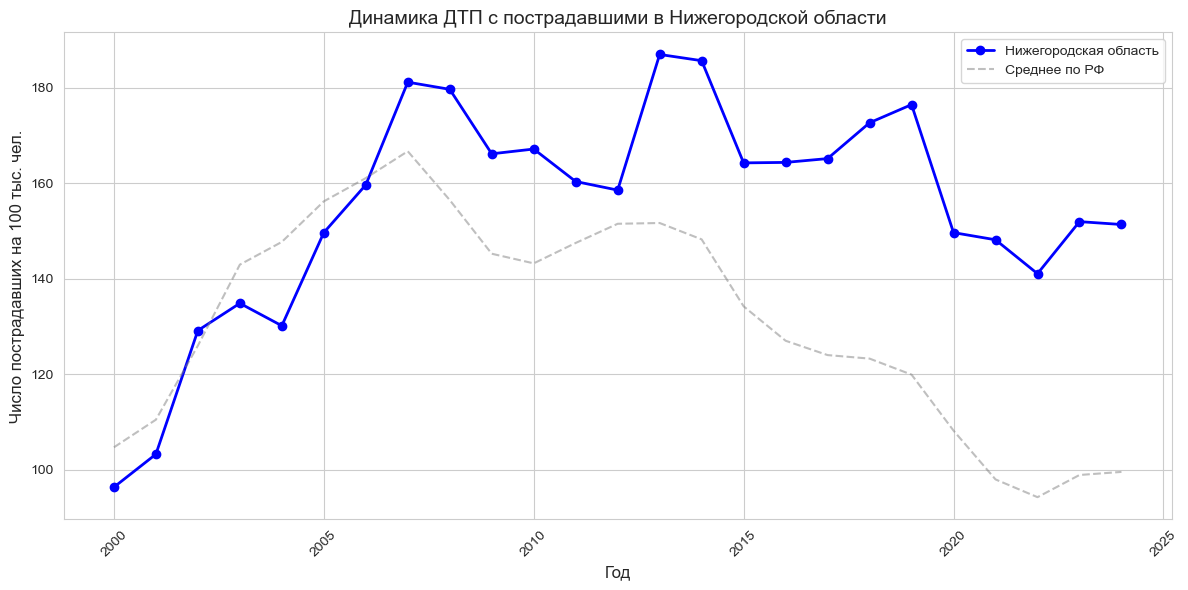

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns

if df.index.name != 'Регион':
    df_plot = df.set_index('Регион')
else:
    df_plot = df.copy()

# 2. Выбираем данные только по Нижегородской области
# Используем .loc для выбора строки по названию
nizhny_data = df_plot.loc[['Нижегородская область']]

# 3. Транспонируем, чтобы годы стали строками, а значения — колонкой
nizhny_data = nizhny_data.T

# 4. Визуализация
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.plot(nizhny_data.index, nizhny_data['Нижегородская область'], 
         marker='o', color='blue', linewidth=2, label='Нижегородская область')

# Добавим среднюю линию для контекста (опционально)
mean_val = df_plot.mean()
plt.plot(mean_val.index, mean_val.values, 
         linestyle='--', color='gray', alpha=0.5, label='Среднее по РФ')

plt.title('Динамика ДТП с пострадавшими в Нижегородской области', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Число пострадавших на 100 тыс. чел.', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


<Axes: >

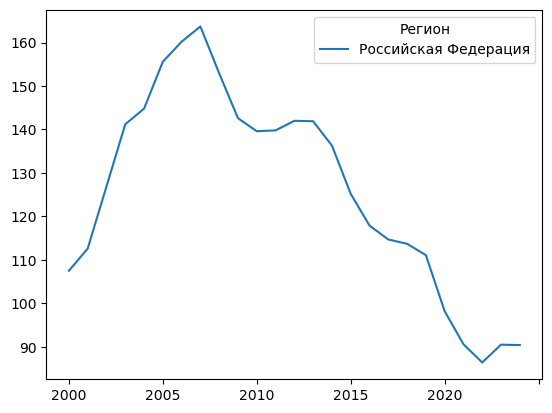

In [6]:
df_plot = df.set_index('Регион')
df_plot[df_plot.index=='Российская Федерация'].T.plot()